# **Project 3 | Matrix Factorization Methods**

# by Sandra Dela Cruz

In [205]:
# import libraries
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from collections import defaultdict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix

In [206]:
# import dataset from GitHub
# original data source: https://grouplens.org/datasets/movielens/
!git clone https://github.com/lalaexplore/DATA-612.git

links = pd.read_csv('DATA-612/project 2/links.csv')
movies = pd.read_csv('DATA-612/project 2/movies.csv')
ratings = pd.read_csv('DATA-612/project 2/ratings.csv')
tags = pd.read_csv('DATA-612/project 2/tags.csv')

full_df = pd.merge(movies, ratings, on='movieId', how='left')

full_df.info()
full_df.head()

fatal: destination path 'DATA-612' already exists and is not an empty directory.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100854 entries, 0 to 100853
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   movieId    100854 non-null  int64  
 1   title      100854 non-null  object 
 2   genres     100854 non-null  object 
 3   userId     100836 non-null  float64
 4   rating     100836 non-null  float64
 5   timestamp  100836 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 4.6+ MB


,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,9.649827e+08
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,8.474350e+08
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,1.106636e+09
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,1.510578e+09
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,1.305696e+09


In [207]:
# Let's see if we have any missing values before splitting the dataset
full_df.isnull().values.any()
full_df.isnull().sum() # shows missing values for each column
full_df.isnull().sum().sum() # we have at least 54 missing values for userId, rating and timestamp
full_df[full_df.isnull().any(axis=1)].head()
# We have 54 missing values for userId, rating and timestamp. We will drop these rows for now since they are not useful for this analysis.

full_df.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,9.649827e+08
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,8.474350e+08
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,1.106636e+09
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,1.510578e+09
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,1.305696e+09


In [208]:
# Drop missing values for our analysis
full_df = full_df.dropna(subset=['userId'])

full_df.isnull().sum() # we have no more missing values for userId, rating and timestamp

movieId      0
title        0
genres       0
userId       0
rating       0
timestamp    0
dtype: int64

In [209]:
# Let's clean our dataset first
full_df['userId'] = full_df['userId'].astype(int)
full_df['movieId'] = full_df['movieId'].astype(int)
full_df['rating'] = full_df['rating'].astype(float)


# Transform timestamp (just in case)
full_df['timestamp'] = pd.to_datetime(full_df['timestamp'], unit='s')
full_df['year'] = full_df['timestamp'].dt.year
full_df['month'] = full_df['timestamp'].dt.month
full_df['day'] = full_df['timestamp'].dt.day
full_df['hour'] = full_df['timestamp'].dt.hour
full_df['minute'] = full_df['timestamp'].dt.minute
full_df['second'] = full_df['timestamp'].dt.second

full_df.head()

,movieId,title,genres,userId,rating,timestamp,year,month,day,hour,minute,second
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,2000-07-30 18:45:03,2000,7,30,18,45,3
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,1996-11-08 06:36:02,1996,11,8,6,36,2
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,2005-01-25 06:52:26,2005,1,25,6,52,26
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,2017-11-13 12:59:30,2017,11,13,12,59,30
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,2011-05-18 05:28:03,2011,5,18,5,28,3


In [210]:
# Final check before we proceed
full_df.info()
full_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 100836 entries, 0 to 100853
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   movieId    100836 non-null  int64         
 1   title      100836 non-null  object        
 2   genres     100836 non-null  object        
 3   userId     100836 non-null  int64         
 4   rating     100836 non-null  float64       
 5   timestamp  100836 non-null  datetime64[ns]
 6   year       100836 non-null  int32         
 7   month      100836 non-null  int32         
 8   day        100836 non-null  int32         
 9   hour       100836 non-null  int32         
 10  minute     100836 non-null  int32         
 11  second     100836 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(6), int64(2), object(2)
memory usage: 7.7+ MB


,movieId,title,genres,userId,rating,timestamp,year,month,day,hour,minute,second
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,2000-07-30 18:45:03,2000,7,30,18,45,3
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,1996-11-08 06:36:02,1996,11,8,6,36,2
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,2005-01-25 06:52:26,2005,1,25,6,52,26
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,2017-11-13 12:59:30,2017,11,13,12,59,30
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,2011-05-18 05:28:03,2011,5,18,5,28,3


# Data Split

In [211]:
# Let's split the dataset into training and testing sets
# Let's guarantee that the userId and movieId are consistent across both sets

train = []
test = []

for uid, group in full_df.groupby('userId'):
    group = group.sample(frac=1, random_state=52) # shuffle the group

    if len(group) < 2:
        train.append(group) # if the user has only 1 rating, put it in the training set
        continue

    split = int(len(group) * 0.8) # 80% for training, 20% for testing

    train.append(group.iloc[:split]) # use iloc for positional indexing (split by row)
    test.append(group.iloc[split:])

train = pd.concat(train, ignore_index=True)
test = pd.concat(test, ignore_index=True)

# Let's see if splitting worked
print("Train size:", len(train))
print("Test size:", len(test))

print("Total:", len(train) + len(test))
print("Original:", len(full_df))

Train size: 80419
Test size: 20417
Total: 100836
Original: 100836


In [212]:
# See if there are users in the test set that are not in the training set
train_users = set(train['userId']) 
test_users = set(test['userId'])

print ("Users only in test:",
       len(test_users - train_users))


Users only in test: 0


In [213]:
# See if there are movies in test set that are not in the training set
train_movies = set(train['movieId'])
test_movies = set(test['movieId'])

print ("Movies only in test:",
       len(test_movies - train_movies))

Movies only in test: 761


In [214]:
# Since some movies appear only in the test set, move them back to the training set
mask = test['movieId'].isin(train_movies)

train = pd.concat([train, test.loc[~mask]], ignore_index=True)
test = test.loc[mask].reset_index(drop=True)

train_movies = set(train['movieId'])
test_movies = set(test['movieId'])

print ("Movies only in test:",
       len(test_movies - train_movies))

Movies only in test: 0


In [215]:
# Verify rows removed
print("Train size:", len(train))
print("Test size after filtering:", len(test))

Train size: 81251
Test size after filtering: 19585


In [216]:
# Check again for our dataset
print(
    "Unseen users:",
    len(set(test['userId']) - set(train['userId']))
)

print(
    "Unseen movies:",
    len(set(test['movieId']) - set(train['movieId']))
)

# Finally, there are no userId and movieId that are not seen on our training data

Unseen users: 0
Unseen movies: 0


# Part 1: SGD Matrix Factorization

In [217]:
# ==========================================
# Create user and movie index mappings
# Map user/movie IDs to contiguous indices so latent factor matrices
# can be stored as dense NumPy arrays and indexed efficiently
# Convert sparse IDs to dense consecutive indices for matrix factorization
# ==========================================

user_ids = train['userId'].unique()
movie_ids = train['movieId'].unique()

user_to_idx = {uid: idx for idx, uid in enumerate(user_ids)}
movie_to_idx = {mid: idx for idx, mid in enumerate(movie_ids)}

n_users = len(user_ids)
n_movies = len(movie_ids)

print(n_users, n_movies)

610 9724


In [218]:
# Build reusable training function for SGD MF
# ==========================================
# Initialize latent factors
# μ = global mean rating
# bu = user bias
# bi = movie bias
# P = user latent factors
# Q = movie latent factors
# ==========================================

def train_sgd_mf(
        train,
        user_to_idx,
        movie_to_idx,
        n_users,
        n_movies,
        k=20, # latent dimensions
        lr=0.01, # learning rate, too big = unstable, too small = slow learning
        reg=0.02, # regularization, prevents overfitting
        epochs=20,
        seed=52
):
    
    mu = train['rating'].mean()

    bu = np.zeros(n_users)
    bi = np.zeros(n_movies)

    rng = np.random.default_rng(seed)

    P = np.random.normal(0, 0.1, (n_users, k))
    Q = np.random.normal(0, 0.1, (n_movies, k))
    
    # Convert training data to index form
    train_data = [
        (user_to_idx[r.userId], movie_to_idx[r.movieId], r.rating)
        for r in train.itertuples()
    ]

    for epoch in range(epochs):
        rng.shuffle(train_data) # for reproducibility
        # ==========================================
        # predicting ratings
        # measuring error
        # nudging user/movie vectors + biases to reduce that error
        # ==========================================

        np.random.shuffle(train_data)

        total_error = 0 # compute RMSE at the end of epoch to see if our model progresses, important for early stopping

        for u, i, r in train_data:

            pred = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])
            err = r - pred

            total_error += err**2

            bu[u] += lr * (err - reg * bu[u])
            bi[i] += lr * (err - reg * bi[i])

            # Save copies for simultaneous update
            # Without copying, updates would interfere with each other
            p_old = P[u].copy()

            P[u] += lr * (err * Q[i] - reg * P[u])
            Q[i] += lr * (err * p_old - reg * Q[i])

        rmse = np.sqrt(total_error / len(train_data))
        print(f"Epoch {epoch+1}: RMSE={rmse:.4f}")

# return AFTER all epochs are finished
    return {
        "mu": mu,
        "bu": bu,
        "bi": bi,
        "P": P,
        "Q": Q,
        "user_to_idx": user_to_idx,
        "movie_to_idx": movie_to_idx
    }

sgd_model = train_sgd_mf(train, user_to_idx, movie_to_idx, n_users, n_movies)

sgd_model

Epoch 1: RMSE=0.9449
Epoch 2: RMSE=0.8918
Epoch 3: RMSE=0.8721
Epoch 4: RMSE=0.8585
Epoch 5: RMSE=0.8476
Epoch 6: RMSE=0.8380
Epoch 7: RMSE=0.8286
Epoch 8: RMSE=0.8189
Epoch 9: RMSE=0.8085
Epoch 10: RMSE=0.7969
Epoch 11: RMSE=0.7842
Epoch 12: RMSE=0.7698
Epoch 13: RMSE=0.7542
Epoch 14: RMSE=0.7375
Epoch 15: RMSE=0.7204
Epoch 16: RMSE=0.7029
Epoch 17: RMSE=0.6858
Epoch 18: RMSE=0.6691
Epoch 19: RMSE=0.6531
Epoch 20: RMSE=0.6379


{'mu': np.float64(3.4988061685394642),
 'bu': array([ 7.07638047e-01,  1.87856647e-01, -1.28221748e+00, -4.34094581e-01,
        -5.68494011e-02,  1.19304974e-01, -3.22137415e-01, -1.39030924e-01,
        -2.68978776e-01, -4.35634123e-01,  2.23069382e-01,  9.45195386e-01,
         6.67569254e-02, -1.26054040e-02, -2.35457037e-01, -2.51006820e-01,
         1.76488233e-01, -3.22654577e-02, -7.93223531e-01,  6.39632129e-02,
        -2.96919278e-01, -1.12899243e+00, -3.22098096e-01, -1.29545657e-01,
         8.88451737e-01, -3.12983281e-01, -1.45177715e-01, -7.64366290e-01,
         1.76937345e-01,  6.53070180e-01,  3.53944152e-01,  1.09253995e-01,
         1.00071436e-01, -2.61026934e-01,  4.89608550e-01, -7.90119992e-01,
         3.54511791e-01, -3.17113034e-01, -5.86600615e-02,  3.09106204e-01,
        -3.83444141e-01,  3.60639188e-02,  1.22109586e+00, -7.20877748e-02,
         2.71459303e-01,  4.82318328e-01, -6.14941072e-01,  4.33541794e-01,
         3.19959038e-01, -9.42381590e-01,  

In [219]:
# Build reusable prediction function for SGD MF
def predict_sgd(
        user_id,
        movie_id,
        model
):
    mu = model["mu"]

    user_known = user_id in model["user_to_idx"]
    movie_known = movie_id in model["movie_to_idx"]

    if user_known and movie_known:
        u = model["user_to_idx"][user_id]
        i = model["movie_to_idx"][movie_id]

        pred =(
            mu
            + model["bu"][u]
            + model["bi"][i]
            + np.dot(model["P"][u], model["Q"][i])
        )
    
    elif user_known:
        u = model["user_to_idx"][user_id]
        return mu + model["bu"][u]
    
    elif movie_known:
        i = model["movie_to_idx"][movie_id]
        return mu + model["bi"][i]
    
    else:
        pred = mu
    
    return np.clip(pred, 1, 5)


## Sample Use

In [220]:
def recommend_movies_sgd(
        user_id,
        model,
        train,
        n_recommendations=10
):
    """
    Recommend movies using a trained matrix factorization
    model (SGD) and return the top-N unseen movies
    ranked by predicted rating.
    """

    # Check if user exists in the model
    if user_id not in model["user_to_idx"]:
        return pd.Series(dtype=float)

    # Movies already rated by the user
    rated_movies = train.loc[user_id].dropna().index

    # Movies not yet rated
    unseen_movies = [
        movie_id
        for movie_id in model["movie_to_idx"].keys()
        if movie_id not in rated_movies
    ]

    predictions = {}

    for movie_id in unseen_movies:

        # Matrix factorization prediction
        pred = predict_sgd(
            user_id=user_id,
            movie_id=movie_id,
            model=model
        )

        predictions[movie_id] = pred

    recommendations = (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(n_recommendations)
    )

    return recommendations

In [221]:
# Sort recommendations
recommendations_sgd = recommend_movies_sgd(
    user_id=1,
    model=sgd_model,
    train=train,
    n_recommendations=10
)

print(recommendations_sgd)

3266      5.0
99114     5.0
171763    5.0
158966    5.0
608       5.0
778       5.0
38061     5.0
50        5.0
260       5.0
8132      5.0
dtype: float64


In [222]:
# Convert IDs to titles
top_movie_ids_sgd = recommendations_sgd.index

movies[
    movies["movieId"].isin(top_movie_ids_sgd)
][["movieId", "title"]]

,movieId,title
46,50,"Usual Suspects, The (1995)"
224,260,Star Wars: Episode IV - A New Hope (1977)
520,608,Fargo (1996)
613,778,Trainspotting (1996)
2453,3266,Man Bites Dog (C'est arrivé près de chez vous)...
5110,8132,Gladiator (1992)
6016,38061,Kiss Kiss Bang Bang (2005)
8063,99114,Django Unchained (2012)
9301,158966,Captain Fantastic (2016)
9521,171763,Baby Driver (2017)


# Psrt 2: ALS Matrix Factorization

In [223]:
# ==========================================
# Let's try building a reusable ALS dataset structure, for organization and reusability
# This is helpful for rebuilding data for different train/test splits
# Helps with fewer global variables
# And later package the recommender into reusable module
# ==========================================

def prepare_als_data(train):

    user_ids = train['userId'].unique()
    movie_ids = train['movieId'].unique()

    user_to_idx = {
        uid: idx
        for idx, uid in enumerate(user_ids)
    }

    movie_to_idx = {
        mid: idx
        for idx, mid in enumerate(movie_ids)
    }

    user_ratings = defaultdict(list)
    movie_ratings = defaultdict(list)

    for row in train.itertuples():

        u = user_to_idx[row.userId]
        i = movie_to_idx[row.movieId]
        r = row.rating

        user_ratings[u].append((i, r))
        movie_ratings[i].append((u, r))

    return{
        "mu": train["rating"].mean(),
        "user_ratings": user_ratings,
        "movie_ratings": movie_ratings,
        "user_to_idx": user_to_idx,
        "movie_to_idx": movie_to_idx,
        "n_users": len(user_ids),
        "n_movies": len(movie_ids)
    }

In [224]:
# =====================================================
# Build reusable training function for ALS MF
# Parameters
# ----------
# k : latent dimensions
# reg_bias : regularization for user/movie biases
# reg_factor : regularization for latent factors
# epochs : ALS iterations
# =====================================================

def train_als_mf(
        als_data,
        k=50,
        reg_bias=10,
        reg_factor=0.05,
        epochs=20,
        random_state=None
):
    if random_state is not None:
        np.random.seed(random_state)

    """
    ALS Matrix Factorization with:

        r_hat = mu + bu + bi + P·Q
    """
    mu = als_data["mu"]

    user_ratings = als_data["user_ratings"]
    movie_ratings = als_data["movie_ratings"]

    user_to_idx = als_data["user_to_idx"]
    movie_to_idx = als_data["movie_to_idx"]

    n_users = als_data["n_users"]
    n_movies = als_data["n_movies"]


    # =====================================================
    # Bias terms
    # =====================================================

    bu = np.zeros(n_users)
    bi = np.zeros(n_movies)

    # =====================================================
    # Latent factor matrices
    # =====================================================

    P = np.random.normal(0, 0.1, (n_users, k))
    Q = np.random.normal(0, 0.1, (n_movies, k))

    I = np.eye(k)

    # =====================================================
    # ALS LOOP
    # =====================================================

    for epoch in range(epochs):

        # =================================================
        # Update User Biases
        # =================================================

        for u in range(n_users):

            ratings = user_ratings[u]

            if len(ratings) == 0:
                continue

            residual_sum = 0

            for i, rating in ratings:

                residual_sum += (
                    rating
                    - mu
                    - bi[i]
                    - np.dot(P[u], Q[i])
                )

            bu[u] = residual_sum / (reg_bias + len(ratings))

        # =================================================
        # Update Movie Biases
        # =================================================

        for i in range(n_movies):

            ratings = movie_ratings[i]

            if len(ratings) == 0:
                continue

            residual_sum = 0

            for u, rating in ratings:

                residual_sum += (
                    rating
                    - mu
                    - bu[u]
                    - np.dot(P[u], Q[i])
                )

            bi[i] = residual_sum / (reg_bias + len(ratings))

        # =================================================
        # Update User Factors
        # =================================================

        for u in range(n_users):

            ratings = user_ratings[u]

            if len(ratings) == 0:
                continue

            movie_idxs = [i for i, _ in ratings]

            r = np.array([
                rating
                - mu
                - bu[u]
                - bi[i]
                for i, rating in ratings
            ])

            Q_u = Q[movie_idxs]

            A = Q_u.T @ Q_u + reg_factor * I
            b = Q_u.T @ r

            P[u] = np.linalg.solve(A, b)

        # =================================================
        # Update Movie Factors
        # =================================================

        for i in range(n_movies):

            ratings = movie_ratings[i]

            if len(ratings) == 0:
                continue

            user_idxs = [u for u, _ in ratings]

            r = np.array([
                rating
                - mu
                - bu[u]
                - bi[i]
                for u, rating in ratings
            ])

            P_i = P[user_idxs]

            A = P_i.T @ P_i + reg_factor * I
            b = P_i.T @ r

            Q[i] = np.linalg.solve(A, b)

        # =================================================
        # Training RMSE
        # =================================================

        total_error = 0
        n_obs = 0

        for u, ratings in user_ratings.items():

            for i, rating in ratings:

                pred = (
                    mu
                    + bu[u]
                    + bi[i]
                    + np.dot(P[u], Q[i])
                )

                pred = np.clip(pred, 1, 5)

                total_error += (rating - pred) ** 2
                n_obs += 1

        rmse = np.sqrt(total_error / n_obs)

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"RMSE={rmse:.4f}"
        )

    # =====================================================
    # Return model
    # =====================================================

    return {
        "mu": mu,
        "bu": bu,
        "bi": bi,
        "P": P,
        "Q": Q,
        "k": k,
        "reg_bias": reg_bias,
        "reg_factor": reg_factor,
        "user_to_idx": user_to_idx,
        "movie_to_idx": movie_to_idx
    }

als_data = prepare_als_data(train)

In [225]:
# Build model
als_model = train_als_mf(
    als_data,
    k=50,
    reg_bias=10,
    reg_factor=0.1,
    epochs=20,
    random_state=52
)

/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: divide by zero encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: overflow encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: invalid value encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: divide by zero encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: overflow encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: invalid value encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ip

Epoch 1/20 RMSE=0.2463
Epoch 2/20 RMSE=0.1860
Epoch 3/20 RMSE=0.1550
Epoch 4/20 RMSE=0.1355
Epoch 5/20 RMSE=0.1219
Epoch 6/20 RMSE=0.1119
Epoch 7/20 RMSE=0.1043
Epoch 8/20 RMSE=0.0982
Epoch 9/20 RMSE=0.0933
Epoch 10/20 RMSE=0.0893
Epoch 11/20 RMSE=0.0859
Epoch 12/20 RMSE=0.0831
Epoch 13/20 RMSE=0.0807
Epoch 14/20 RMSE=0.0787
Epoch 15/20 RMSE=0.0769
Epoch 16/20 RMSE=0.0754
Epoch 17/20 RMSE=0.0742
Epoch 18/20 RMSE=0.0730
Epoch 19/20 RMSE=0.0720
Epoch 20/20 RMSE=0.0712


In [226]:
# Build reusable prediction function for ALS MF
def predict_als(
        user_id,
        movie_id,
        model
):
    mu = model["mu"]

    user_known = model["user_to_idx"]
    movie_known = model["movie_to_idx"]

    if user_known and movie_known:
        u = model["user_to_idx"][user_id]
        i = model["movie_to_idx"][movie_id]

        pred = (
            mu
            + model["bu"][u]
            + model["bi"][i]
            + np.dot(model["P"][u], model["Q"][i])
        )
    
    elif user_known:
        u = model["user_to_idx"][user_id]
        return mu + model["bu"][u]
    
    elif movie_known:
        i = model["movie_to_idx"][movie_id]
        return mu + model["bi"][i]
    
    else:
        pred = mu
    
    return np.clip(pred, 1, 5)

## Sample Use

In [227]:
def recommend_movies_sgd(
        user_id,
        model,
        train,
        n_recommendations=10
):
    """
    Recommend movies using a trained matrix factorization
    model (SGD) and return the top-N unseen movies
    ranked by predicted rating.
    """

    # Check if user exists in the model
    if user_id not in model["user_to_idx"]:
        return pd.Series(dtype=float)

    u = model["user_to_idx"][user_id]

    # Movies already rated by the user
    rated_movies = train.loc[user_id].dropna().index

    # Movies not yet rated
    unseen_movies = [
        movie_id
        for movie_id in model["movie_to_idx"].keys()
        if movie_id not in rated_movies
    ]

    predictions = {}

    for movie_id in unseen_movies:
        i = model["movie_to_idx"][movie_id]

        # Matrix factorization prediction
        pred = (
            model["mu"]
            + model["bu"][u]
            + model["bi"][i]
            + np.dot(model["P"][u], model["Q"][i])
        )

        # Keep prediction within rating scale
        pred = np.clip(pred, 1, 5)

        predictions[movie_id] = pred

    recommendations = (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(n_recommendations)
    )

    return recommendations

In [228]:
def recommend_movies_als(
        user_id,
        model,
        als_data,
        n_recommendations=10
):

    if user_id not in model["user_to_idx"]:
        return pd.Series(dtype=float)

    u = model["user_to_idx"][user_id]

    rated_movie_idxs = {
        i
        for i, _ in als_data["user_ratings"][u]
    }

    predictions = {}

    for movie_id, i in model["movie_to_idx"].items():

        if i in rated_movie_idxs:
            continue

        predictions[movie_id] = predict_als(
            user_id,
            movie_id,
            model
        )

    return (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(n_recommendations)
    )

In [229]:
# Sort recommendations
recommendations_als = recommend_movies_als(
    user_id=1,
    model=als_model,
    als_data=als_data,
    n_recommendations=10
)

print(recommendations_als)

3863     5.0
79702    5.0
3160     5.0
6993     5.0
3175     5.0
2908     5.0
111      5.0
48780    5.0
2791     5.0
4886     5.0
dtype: float64


In [230]:
# Convert IDs to titles
top_movie_ids_als = recommendations_als.index

movies[
    movies["movieId"].isin(top_movie_ids_sgd)
][["movieId", "title"]]

,movieId,title
46,50,"Usual Suspects, The (1995)"
224,260,Star Wars: Episode IV - A New Hope (1977)
520,608,Fargo (1996)
613,778,Trainspotting (1996)
2453,3266,Man Bites Dog (C'est arrivé près de chez vous)...
5110,8132,Gladiator (1992)
6016,38061,Kiss Kiss Bang Bang (2005)
8063,99114,Django Unchained (2012)
9301,158966,Captain Fantastic (2016)
9521,171763,Baby Driver (2017)


# Part 3: Overall RMSE and MAE Evaluation

In [231]:
def evaluate_rmse_mae(
        test_data,
        prediction_fuction,
        **kwargs
):
    actual = []
    predicted = []

    for row in test_data.itertuples():
        
        pred = prediction_fuction(
            user_id=row.userId,
            movie_id=row.movieId,
            **kwargs
        )

        if not np.isnan(pred):
            actual.append(row.rating)
            predicted.append(pred)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    return rmse, mae

In [232]:
# SVD via SGD
svd_sgd_rmse, svd_sgd_mae = evaluate_rmse_mae(
    test,
    predict_sgd,
    model=sgd_model
)

print(f"RMSE SVD via SGD: {svd_sgd_rmse:.3f}")
print(f"MAE SVD via SGD: {svd_sgd_mae:.3f}")

RMSE SVD via SGD: 0.872
MAE SVD via SGD: 0.667


In [233]:
# ALS
als_rmse, als_mae = evaluate_rmse_mae(
    test,
    predict_sgd,
    model=als_model
)

print(f"RMSE ALS: {als_rmse:.3f}")
print(f"MAE ALS: {als_mae:.3f}")

RMSE ALS: 1.108
MAE ALS: 0.848


## Part 4: Overall Precision@K and Recall@K

In [234]:
def get_top_k_recommendations(
        user_id,
        prediction_function,
        train,
        model,
        k_recommendations=20,
        candidate_size=3000
):
    
    # Movies already rated by user
    rated_movies = set(
        train.loc[
            train["userId"] == user_id,
            "movieId"
        ]
    )

    # Movies not rated
    all_movies = train["movieId"].unique()

    unrated_movies = [
        movie_id
        for movie_id in all_movies
        if movie_id not in rated_movies
    ]

    if len(unrated_movies) > candidate_size:
        unrated_movies = np.random.choice(
            unrated_movies,
            size=candidate_size,
            replace=False
        )
    
    predictions = {}

    for movie_id in unrated_movies:

        pred = prediction_function(
            user_id=user_id,
            movie_id=movie_id,
            model=model
        )

        if not np.isnan(pred):
            predictions[movie_id] = pred

    if len(predictions) == 0:
        return []
    
    return (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(k_recommendations)
        .index
        .tolist()
    )

In [235]:
def precision_recall_at_k(
    test_data,
    train_data,
    prediction_function,
    model,
    k=20,
    threshold=3.5
):

    precisions = []
    recalls = []

    users = test_data['userId'].unique()

    for user in users:

        actual_relevant = set(
            test_data[
                (test_data['userId'] == user) &
                (test_data['rating'] >= threshold)
            ]['movieId']
        )

        if len(actual_relevant) == 0:
            continue

        recommended = set(
            get_top_k_recommendations(
                user_id=user,
                prediction_function=prediction_function,
                train=train_data,
                model=model,
                k_recommendations=k
            )
        )

        true_positives = len(
            recommended.intersection(actual_relevant)
        )

        precisions.append(true_positives / k)

        recalls.append(
            true_positives / len(actual_relevant)
        )


    return np.mean(precisions), np.mean(recalls)

In [236]:
svd_sgd_precision, svd_sgd_recall = precision_recall_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_sgd,
    model=sgd_model,
    k=20
)

print(f"Precision@20 SVD via SGD: {svd_sgd_precision:.3f}")
print(f"Recall@20 SVD via SGD: {svd_sgd_recall:.3f}")

Precision@20 SVD via SGD: 0.027
Recall@20 SVD via SGD: 0.029


In [237]:
als_precision, als_recall = precision_recall_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_sgd,
    model=sgd_model,
    k=20
)

print(f"Precision@20 ALS: {als_precision:.3f}")
print(f"Recall@20 ALS: {als_recall:.3f}")

Precision@20 ALS: 0.028
Recall@20 ALS: 0.030


## Part 5: Final Comparison Table and Graph

In [238]:
results = pd.DataFrame({
    "RMSE": [
        svd_sgd_rmse,
        als_rmse
    ],
    "MAE": [
        svd_sgd_mae,
        als_mae
    ],
    "Precision@20": [
        svd_sgd_precision,
        als_precision
    ],
    "Recall@20": [
        svd_sgd_recall,
        als_recall
    ]
},
index=[
    "SVD via SGD",
    "ALS"
])

results

,RMSE,MAE,Precision@20,Recall@20
SVD via SGD,0.871714,0.667362,0.027295,0.028896
ALS,1.108376,0.848411,0.027546,0.029803


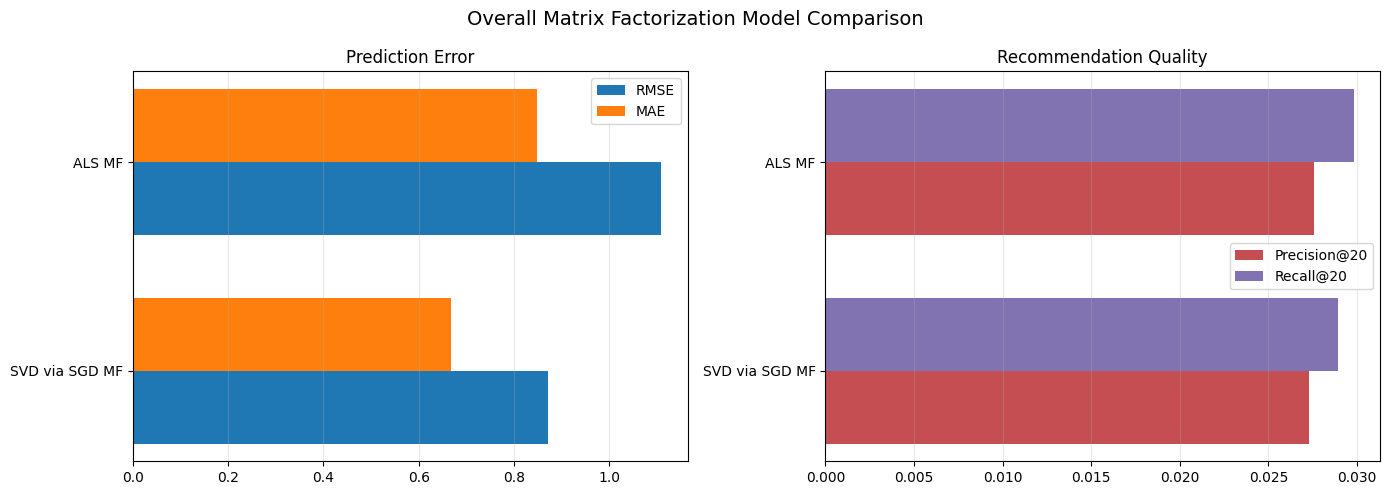

In [239]:
models = ["SVD via SGD MF", "ALS MF"]

rmse_scores = [svd_sgd_rmse, als_rmse]
mae_scores = [svd_sgd_mae, als_mae]

precision = [svd_sgd_precision, als_precision]
recall = [svd_sgd_recall, als_recall]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y = np.arange(len(models))
h = 0.35

# Left: RMSE & MAE (Error Metrics)
axes[0].barh(y - h/2, rmse_scores, h, label="RMSE")
axes[0].barh(y + h/2, mae_scores, h, label="MAE")
axes[0].set_yticks(y)
axes[0].set_yticklabels(models)
axes[0].set_title("Prediction Error")
axes[0].grid(axis="x", alpha=0.3)
axes[0].legend()

# Right: Precision & Recall (Recommendatin Metrics)
axes[1].barh(y - h/2, precision, h, label="Precision@20", color="#C44E52")
axes[1].barh(y + h/2, recall, h, label="Recall@20", color="#8172B2")
axes[1].set_yticks(y)
axes[1].set_yticklabels(models)
axes[1].set_title("Recommendation Quality")
axes[1].grid(axis="x", alpha=0.3)
axes[1].legend()

plt.suptitle("Overall Matrix Factorization Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

SVD via SGD achieved lower RMSE and MAE, indicating more accurate rating predictions. ALS achieved slightly higher Recall@20, suggesting it was able to recover a somewhat larger proportion of relevant items, although its overall prediction accuracy was lower.

# Extra: Tuning ALS MF


In [240]:
def tune_als_mf(
        als_data,
        test,
        k_values=[20, 50, 100],
        reg_factor_values=[0.01, 0.05, 0.1],
        epoch_values=[20, 40]
):
    results = []

    for k in k_values:
        for reg_factor in reg_factor_values:
            for epochs in epoch_values:

                np.random.seed(52)

                model = train_als_mf(
                    als_data,
                    k=k,
                    reg_bias=10,
                    reg_factor=reg_factor,
                    epochs=epochs
                )

                rmse, mae = evaluate_rmse_mae(
                    test,
                    predict_als,
                    model=model
                )

                results.append({
                    "k": k,
                    "reg_factor": reg_factor,
                    "epochs": epochs,
                    "rmse": rmse,
                    "mae": mae
                })

                print(
                    f"k={k}, reg={reg_factor}, epochs={epochs} "
                    f"RMSE={rmse:.4f}, MAE={mae:.4f}"
                )

    return pd.DataFrame(results)

In [241]:
als_data = prepare_als_data(train)

results_df = tune_als_mf(
    als_data,
    test
)

results_df.sort_values("rmse").head()

/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: divide by zero encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: overflow encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: invalid value encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: divide by zero encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: overflow encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: invalid value encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ip

Epoch 1/20 RMSE=0.4485
Epoch 2/20 RMSE=0.4060
Epoch 3/20 RMSE=0.3835
Epoch 4/20 RMSE=0.3685
Epoch 5/20 RMSE=0.3572
Epoch 6/20 RMSE=0.3483
Epoch 7/20 RMSE=0.3408
Epoch 8/20 RMSE=0.3345
Epoch 9/20 RMSE=0.3291
Epoch 10/20 RMSE=0.3244
Epoch 11/20 RMSE=0.3201
Epoch 12/20 RMSE=0.3163
Epoch 13/20 RMSE=0.3129
Epoch 14/20 RMSE=0.3097
Epoch 15/20 RMSE=0.3069
Epoch 16/20 RMSE=0.3042
Epoch 17/20 RMSE=0.3018
Epoch 18/20 RMSE=0.2996
Epoch 19/20 RMSE=0.2975
Epoch 20/20 RMSE=0.2955
k=20, reg=0.01, epochs=20 RMSE=1.3043, MAE=0.9776


/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: divide by zero encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: overflow encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: invalid value encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: divide by zero encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: overflow encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: invalid value encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ip

Epoch 1/40 RMSE=0.4485
Epoch 2/40 RMSE=0.4060
Epoch 3/40 RMSE=0.3835
Epoch 4/40 RMSE=0.3685
Epoch 5/40 RMSE=0.3572
Epoch 6/40 RMSE=0.3483
Epoch 7/40 RMSE=0.3408
Epoch 8/40 RMSE=0.3345
Epoch 9/40 RMSE=0.3291
Epoch 10/40 RMSE=0.3244
Epoch 11/40 RMSE=0.3201
Epoch 12/40 RMSE=0.3163
Epoch 13/40 RMSE=0.3129
Epoch 14/40 RMSE=0.3097
Epoch 15/40 RMSE=0.3069
Epoch 16/40 RMSE=0.3042
Epoch 17/40 RMSE=0.3018
Epoch 18/40 RMSE=0.2996
Epoch 19/40 RMSE=0.2975
Epoch 20/40 RMSE=0.2955
Epoch 21/40 RMSE=0.2937
Epoch 22/40 RMSE=0.2920
Epoch 23/40 RMSE=0.2904
Epoch 24/40 RMSE=0.2888
Epoch 25/40 RMSE=0.2874
Epoch 26/40 RMSE=0.2860
Epoch 27/40 RMSE=0.2847
Epoch 28/40 RMSE=0.2835
Epoch 29/40 RMSE=0.2823
Epoch 30/40 RMSE=0.2811
Epoch 31/40 RMSE=0.2801
Epoch 32/40 RMSE=0.2791
Epoch 33/40 RMSE=0.2781
Epoch 34/40 RMSE=0.2772
Epoch 35/40 RMSE=0.2763
Epoch 36/40 RMSE=0.2754
Epoch 37/40 RMSE=0.2746
Epoch 38/40 RMSE=0.2738
Epoch 39/40 RMSE=0.2731
Epoch 40/40 RMSE=0.2724
k=20, reg=0.01, epochs=40 RMSE=1.3068, MAE=0.9819

/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: divide by zero encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: overflow encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: invalid value encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: divide by zero encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: overflow encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: invalid value encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ip

...

/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: divide by zero encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: overflow encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: invalid value encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: divide by zero encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: overflow encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: invalid value encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ip

Epoch 1/20 RMSE=0.1132
Epoch 2/20 RMSE=0.0725
Epoch 3/20 RMSE=0.0636
Epoch 4/20 RMSE=0.0610
Epoch 5/20 RMSE=0.0600
Epoch 6/20 RMSE=0.0596
Epoch 7/20 RMSE=0.0594
Epoch 8/20 RMSE=0.0593
Epoch 9/20 RMSE=0.0592
Epoch 10/20 RMSE=0.0591
Epoch 11/20 RMSE=0.0591
Epoch 12/20 RMSE=0.0591
Epoch 13/20 RMSE=0.0591
Epoch 14/20 RMSE=0.0591
Epoch 15/20 RMSE=0.0590
Epoch 16/20 RMSE=0.0590
Epoch 17/20 RMSE=0.0590
Epoch 18/20 RMSE=0.0590
Epoch 19/20 RMSE=0.0590
Epoch 20/20 RMSE=0.0590
k=100, reg=0.1, epochs=20 RMSE=0.9504, MAE=0.7302


/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: divide by zero encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: overflow encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:132: RuntimeWarning: invalid value encountered in matmul
  A = Q_u.T @ Q_u + reg_factor * I
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: divide by zero encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: overflow encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ipykernel_709/2079255607.py:133: RuntimeWarning: invalid value encountered in matmul
  b = Q_u.T @ r
/var/folders/6g/5jxdtg9d6vd36fmxhrjfkn5m0000gn/T/ip

Epoch 1/40 RMSE=0.1132
Epoch 2/40 RMSE=0.0725
Epoch 3/40 RMSE=0.0636
Epoch 4/40 RMSE=0.0610
Epoch 5/40 RMSE=0.0600
Epoch 6/40 RMSE=0.0596
Epoch 7/40 RMSE=0.0594
Epoch 8/40 RMSE=0.0593
Epoch 9/40 RMSE=0.0592
Epoch 10/40 RMSE=0.0591
Epoch 11/40 RMSE=0.0591
Epoch 12/40 RMSE=0.0591
Epoch 13/40 RMSE=0.0591
Epoch 14/40 RMSE=0.0591
Epoch 15/40 RMSE=0.0590
Epoch 16/40 RMSE=0.0590
Epoch 17/40 RMSE=0.0590
Epoch 18/40 RMSE=0.0590
Epoch 19/40 RMSE=0.0590
Epoch 20/40 RMSE=0.0590
Epoch 21/40 RMSE=0.0590
Epoch 22/40 RMSE=0.0590
Epoch 23/40 RMSE=0.0590
Epoch 24/40 RMSE=0.0590
Epoch 25/40 RMSE=0.0590
Epoch 26/40 RMSE=0.0590
Epoch 27/40 RMSE=0.0590
Epoch 28/40 RMSE=0.0590
Epoch 29/40 RMSE=0.0590
Epoch 30/40 RMSE=0.0590
Epoch 31/40 RMSE=0.0590
Epoch 32/40 RMSE=0.0590
Epoch 33/40 RMSE=0.0590
Epoch 34/40 RMSE=0.0590
Epoch 35/40 RMSE=0.0590
Epoch 36/40 RMSE=0.0590
Epoch 37/40 RMSE=0.0590
Epoch 38/40 RMSE=0.0590
Epoch 39/40 RMSE=0.0590
Epoch 40/40 RMSE=0.0590
k=100, reg=0.1, epochs=40 RMSE=0.9320, MAE=0.7172

,k,reg_factor,epochs,rmse,mae
17,100,0.10,40,0.932047,0.717225
16,100,0.10,20,0.950363,0.730184
15,100,0.05,40,0.963077,0.738923
14,100,0.05,20,0.992780,0.759537
13,100,0.01,40,1.067113,0.813420


# Summary

In this project, we again used the MovieLens dataset containing approximately 100,000 movie ratings to evaluate latent factor recommendation methods. We implemented and compared two matrix factorization approaches: Singular Value Decomposition (SVD) trained using Stochastic Gradient Descent (SGD) and Alternating Least Squares (ALS). Compared with our previous neighborhood-based collaborative filtering models, including user-user Pearson correlation, user-user cosine similarity, and item-item cosine similarity, the matrix factorization approaches were more computationally efficient and scaled better to larger datasets.

Using RMSE, MAE, Precision@20, and Recall@20 as evaluation metrics, SVD via SGD achieved the strongest overall predictive performance, while ALS produced slightly higher recall in recommendation ranking. Although the improvements in recommendation quality were modest, both matrix factorization methods were able to capture latent relationships between users and items that neighborhood-based methods may miss. We also observed that incorporating the global mean together with user and item bias terms improved prediction quality by accounting for differences in user rating tendencies and item popularity.

Hyperparameter experiments involving latent dimensions, regularization strength, and training epochs showed that model performance was relatively stable across the tested ranges. Overall, the results suggest that matrix factorization provides an effective and computationally efficient alternative to traditional memory-based collaborative filtering techniques, particularly when working with sparse user-item interaction data.